In [1]:

import os
import glob
import pandas as pd
import numpy as np
import logging
#import esmvalcore.preprocessor
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cftime
import matplotlib
import seaborn as sns
matplotlib.rcParams.update({'font.size': 15})
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from Utils import get_ds_from_ceda

# get standard variable names, settings for plotting, region bounds etc. 
from config import path_archive, model_colors, dark_model_colors

colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',
           'HiLLA_13':'red',
           'HiLLA_15':'green'}


def get_ds(run, var, table, zonal_mean=False):
    file = path_archive+'{r}/{t}/{v}/{r}_{v}.nc'.format(r=run, t=table, v=var)
    ds = xr.open_dataset(file)
    if zonal_mean:
        ds = ds.mean(dim='longitude')
    return ds

def cut_incomplete_years(ds):
    final_year = np.max(ds.time.dt.year.values)
    ds_final_year = ds.sel(time=str(final_year))
    if not len(ds_final_year.time.dt.month.values) == 12:
        ds = ds.sel(time=slice(None, str(final_year-1)))
    return ds

In [2]:
def process(ds):
    ds = ds.sel(time=slice('2050', '2069')).groupby('time.month').mean(dim='time')
    ds = ds.mean(dim='longitude')
    return ds

In [3]:
ds_list = []
for mode_var in tqdm(['h2s04_mmr_nuc', 'h2so4_mmr_acc', 'h2so4_mmr_ait', 'h2so4_mmr_cou']):
    ds = process(get_ds(run = 'u-dm204dn587', var=mode_var, table='AERmon'))
    ds_list.append(ds)
ds_HiLLA_13_UK = xr.merge(ds_list)
ds_HiLLA_13_UK['h2so4_mmr'] = ds_HiLLA_13_UK['h2s04_mmr_nuc'] + ds_HiLLA_13_UK['h2so4_mmr_acc'] + ds_HiLLA_13_UK['h2so4_mmr_ait'] + ds_HiLLA_13_UK['h2so4_mmr_cou']

100%|██████████| 4/4 [01:12<00:00, 18.04s/it]


100%|██████████| 4/4 [01:50<00:00, 27.53s/it]


In [4]:
## repeat for the 15km inj case
ds_list = []
for mode_var in tqdm(['h2s04_mmr_nuc', 'h2so4_mmr_acc', 'h2so4_mmr_ait', 'h2so4_mmr_cou']):
    ds = process(get_ds(run = 'u-dn760', var=mode_var, table='AERmon'))
    ds_list.append(ds)
ds_HiLLA_15_UK = xr.merge(ds_list)
ds_HiLLA_15_UK['h2so4_mmr'] = ds_HiLLA_15_UK['h2s04_mmr_nuc'] + ds_HiLLA_15_UK['h2so4_mmr_acc'] + ds_HiLLA_15_UK['h2so4_mmr_ait'] + ds_HiLLA_15_UK['h2so4_mmr_cou']

100%|██████████| 4/4 [01:10<00:00, 17.61s/it]


In [5]:
### also get CESM: 

def process_CE(ds):
    ds = ds.sel(time=slice('2050', '2069')).groupby('time.month').mean(dim='time')
    ds['h2so4_mmr'] = ds['so4_a1a2a3c1c2c3']*(1/0.9796)
    #ds = ds.mean('lon')
    #ds = ds.rename({'lat':'latitude'})
    return ds

ds_HiLLA_13_CE = process_CE(xr.open_dataset(path_archive+'CESM_data/SO4_burdenZ/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.so4_a1a2a3c1c2c3_zm_Z3.203501-206912.nc'))
ds_HiLLA_15_CE = process_CE(xr.open_dataset(path_archive+'CESM_data/SO4_burdenZ/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.so4_a1a2a3c1c2c3_zm_Z3.203501-206912.nc'))

In [6]:
### and E3SM

def process_E3(ds):
    ds = ds.sel(time=slice('2050', '2069')).groupby('time.month').mean(dim='time')
    ds = ds.mean(dim='lon').rename({'lat':'latitude'})
    return ds
    
ds_HiLLA_13_E3_200 = process_E3(xr.open_dataset(path_archive+'E3SM_data/regridded/Mass_so4/Mass_so4_200.polar.mip.e3sm.01.nc'))
ds_HiLLA_15_E3_200 = process_E3(xr.open_dataset(path_archive+'E3SM_data/regridded/Mass_so4/Mass_so4_200.polar.mip.e3sm.04.nc'))
ds_ssp245_E3_200 = process_E3(xr.open_dataset(path_archive+'E3SM_data/regridded/Mass_so4/Mass_so4_200.polar.mip.e3sm.control.nc'))
    
ds_HiLLA_13_E3_330 = process_E3(xr.open_dataset(path_archive+'E3SM_data/regridded/Mass_so4/Mass_so4_330.polar.mip.e3sm.01.nc'))
ds_HiLLA_15_E3_330 = process_E3(xr.open_dataset(path_archive+'E3SM_data/regridded/Mass_so4/Mass_so4_330.polar.mip.e3sm.04.nc'))
ds_ssp245_E3_330 = process_E3(xr.open_dataset(path_archive+'E3SM_data/regridded/Mass_so4/Mass_so4_330.polar.mip.e3sm.control.nc'))


In [7]:
# use Z3 to check height of the 200 mb level:
Z3_HiLLA_13_E3 = xr.open_dataset(path_archive+'E3SM_data/Z3/Z3.polar.mip.e3sm.control.nc').mean('time')

ds = Z3_HiLLA_13_E3.where(Z3_HiLLA_13_E3.lat<61, drop=True)
ds = ds.where(ds.lat>59, drop=True)
z = ds.mean('ncol').Z3
z.sel(lev=200, method='nearest')

<xarray.DataArray 'Z3' ()> Size: 4B
array(11627.507, dtype=float32)
Coordinates:
    lev      float64 8B 201.0

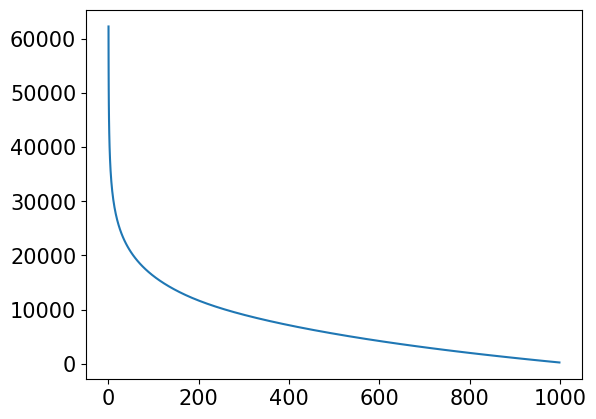

In [8]:
plt.plot(z.lev, z)

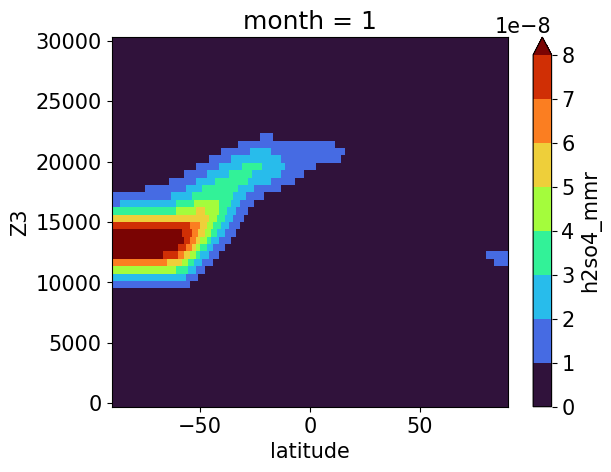

In [9]:
ds_HiLLA_15_CE.isel(month=0).h2so4_mmr.plot(x='latitude', y='Z3', cmap='turbo',
                       levels = np.arange(0, 9E-8, 1E-8))

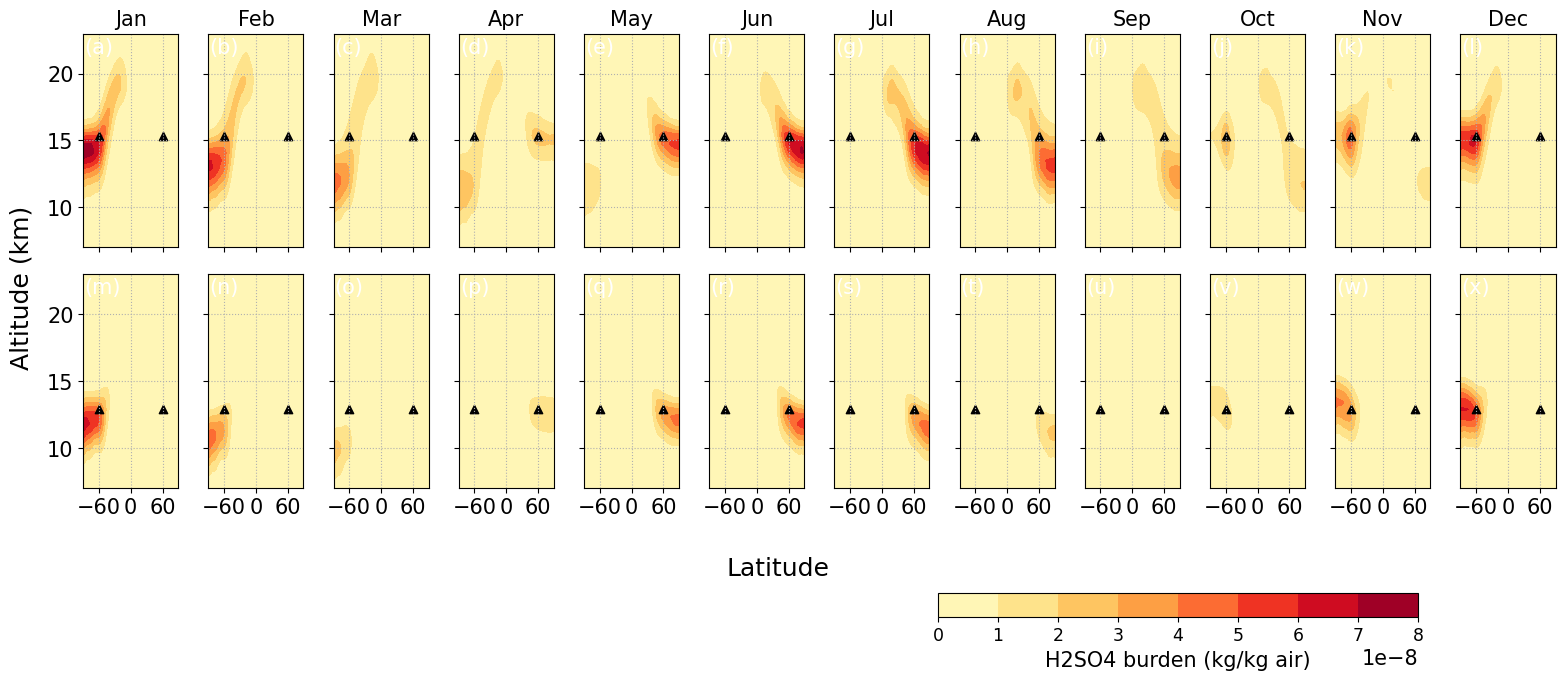

In [49]:
fig, axs = plt.subplots(2, 12, figsize=(16, 6),
                        sharex='all', sharey='all')

heights = [15.36, 12.90]
ds_s = [ds_HiLLA_15_UK, ds_HiLLA_13_UK]
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)', '(m)', '(n)', '(o)', '(p)', '(q)', '(r)', '(s)', '(t)', '(u)', '(v)', '(w)', '(x)']

j=0
i=0
for ds in ds_s:
    for m in ds.month.values:

        colorset = 'YlOrRd'
        ax = axs[j, m-1]
        p = ds.sel(month=m)
        #p = p.where(p.altitude<21000, drop=True)
        
        cs=ax.contourf(p.latitude, 0.001*p.altitude,
                       p.h2so4_mmr, cmap=colorset,
                       levels = np.arange(0, 9E-8, 1E-8))
                       #extend='max')
        
        ax.grid(ls='dotted')
        ax.set_xticks([-60, 0, 60])
        ax.set_ylim(7, 23)
        ax.text(0.01, 0.91, labels[i], transform=ax.transAxes, color='white')
        ax.scatter([60, -60],
                   [heights[j], heights[j]],
                   marker='^', color='black'
                   )
        
        if j == 0:
            ax.set_title(month_names[m], fontsize='medium')
        i=i+1
        
    j=j+1
    
fig.supxlabel('Latitude')
fig.supylabel('Altitude (km)')

plt.tight_layout()

cbar_ax1 = fig.add_axes([0.6, -0.05, 0.3, 0.04])
cbar1 = fig.colorbar(cs, cax=cbar_ax1, orientation='horizontal', label='H2SO4 burden (kg/kg air)')
cbar1.ax.tick_params(labelsize='small')
plt.savefig('Figures/H2SO4_burden_UKESM_bymonth.jpg', dpi=450, bbox_inches='tight')
plt.show()

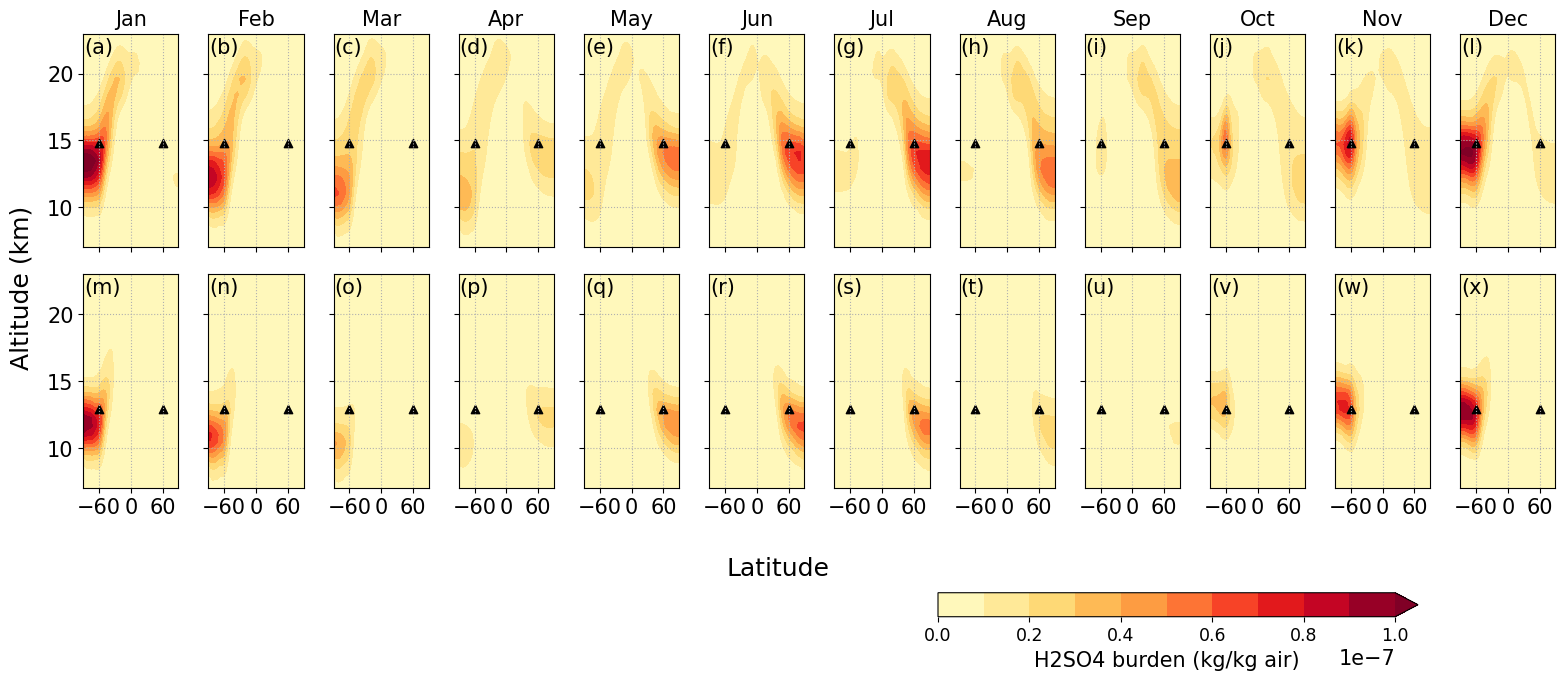

In [47]:
fig, axs = plt.subplots(2, 12, figsize=(16, 6),
                        sharex='all', sharey='all')

heights = [14.8, 12.95]
ds_s = [ds_HiLLA_15_CE, ds_HiLLA_13_CE]
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)', '(j)', '(k)', '(l)', '(m)', '(n)', '(o)', '(p)', '(q)', '(r)', '(s)', '(t)', '(u)', '(v)', '(w)', '(x)']

j=0
i=0
for ds in ds_s:
    for m in ds.month.values:

        colorset = 'YlOrRd'
        
        ax = axs[j, m-1]
        p = ds.sel(month=m)
        #p = p.where(p.Z3<21000, drop=True)
        
        cs=ax.contourf(p.latitude, 0.001*p.Z3,
                       p.h2so4_mmr.transpose(), cmap=colorset,
                       levels = np.arange(0, 1.1E-7, 1E-8),
                       extend='max')
        
        
        ax.grid(ls='dotted')
        ax.set_xticks([-60, 0, 60])
        ax.set_ylim(7, 23)
        ax.text(0.01, 0.91, labels[i], transform=ax.transAxes, color='black')
        ax.scatter([60, -60],
                   [heights[j], heights[j]],
                   marker='^', color='black'
                   )
        
        if j == 0:
            ax.set_title(month_names[m], fontsize='medium')
        i=i+1
        
    j=j+1
    
fig.supxlabel('Latitude')
fig.supylabel('Altitude (km)')

plt.tight_layout()

cbar_ax1 = fig.add_axes([0.6, -0.05, 0.3, 0.04])
cbar1 = fig.colorbar(cs, cax=cbar_ax1, orientation='horizontal', label='H2SO4 burden (kg/kg air)')
cbar1.ax.tick_params(labelsize='small')
plt.savefig('Figures/H2SO4_burden_CESM_bymonth.jpg', dpi=450, bbox_inches='tight')
plt.show()

In [12]:
### report the hemipsheric 11km max: 

## UKESM
print('UKESM')
ds_s = [ds_HiLLA_15_UK, ds_HiLLA_13_UK]


for ds in ds_s:
    test = ds.sel(latitude=slice(0, 91)) # NH only
    test = test.where(test.model_level_number==40, drop=True) # 10.93  11.48 km
    print('max value: ', test.h2so4_mmr.max().values)
    
    args = test.h2so4_mmr.argmax(dim=['month', 'latitude'])
    print('month: ', test.h2so4_mmr.month.values[args['month'].item()])
    print('latitude: ', test.h2so4_mmr.latitude.values[args['latitude'].item()])


## CESM
print('')
print('CESM')
ds_s = [ds_HiLLA_15_CE, ds_HiLLA_13_CE]


for ds in ds_s:
    test = ds.sel(latitude=slice(0, 91)) # NH only
    test = test.sel(Z3=11000, method='nearest') # 10.9
    print('max value: ', test.h2so4_mmr.max().values)
    
    args = test.h2so4_mmr.argmax(dim=['month', 'latitude'])
    print('month: ', test.h2so4_mmr.month.values[args['month'].item()])
    print('latitude: ', test.h2so4_mmr.latitude.values[args['latitude'].item()])


UKESM
max value:  2.8121086e-08
month:  9
latitude:  89.375
max value:  4.6284235e-08
month:  7
latitude:  89.375

CESM
max value:  4.327410713395846e-08
month:  7
latitude:  90.0
max value:  5.7032469308283906e-08
month:  6
latitude:  90.0


In [13]:
### report the 60N 11km max: 

## UKESM
print('UKESM')
ds_s = [ds_HiLLA_15_UK, ds_HiLLA_13_UK]


for ds in ds_s:
    test = ds.sel(latitude=60, method='nearest') #60.6N
    test = test.where(test.model_level_number==40, drop=True) # 10.93  11.48 km
    print('max value: ', test.h2so4_mmr.max().values)
    
    arg = test.h2so4_mmr.argmax(dim='month')
    print('month: ', test.h2so4_mmr.month.values[arg.item()])


## CESM
print('')
print('CESM')
ds_s = [ds_HiLLA_15_CE, ds_HiLLA_13_CE]
for ds in ds_s:
    test = ds.sel(latitude=60, method='nearest') #60.6N
    test = test.sel(Z3=11000, method='nearest') # 10.9
    print('max value: ', test.h2so4_mmr.max().values)
    
    arg = test.h2so4_mmr.argmax(dim='month')
    print('month: ', test.h2so4_mmr.month.values[arg.item()])



UKESM
max value:  1.5527226e-08
month:  9
max value:  2.4922638e-08
month:  6

CESM
max value:  2.2568690969365458e-08
month:  8
max value:  3.279007009967807e-08
month:  6


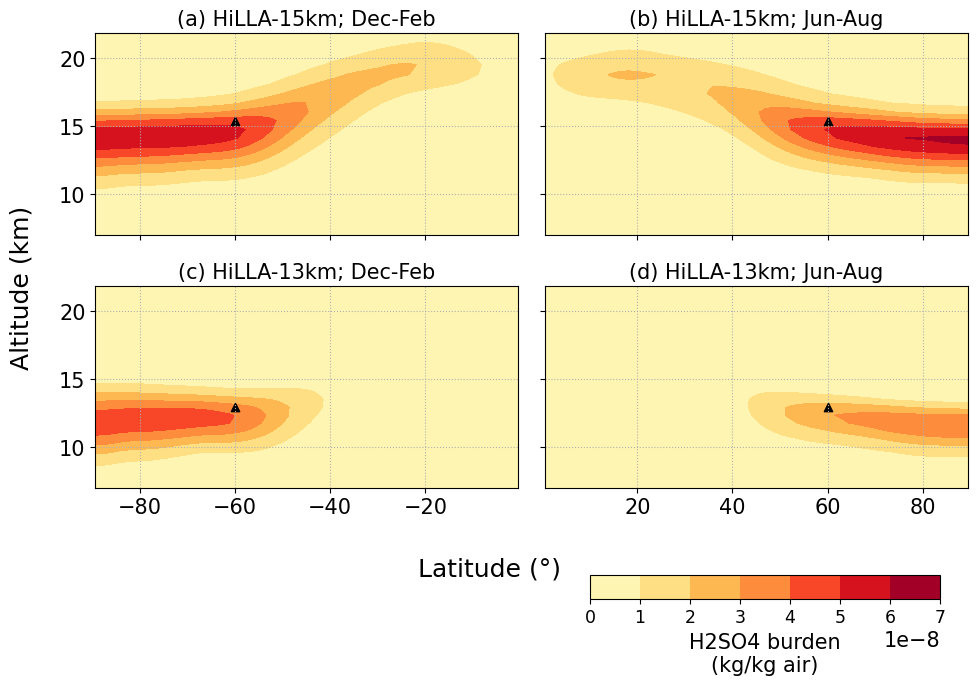

In [29]:
# repeat the plot above, now just summer and winter:

fig, axs = plt.subplots(2, 2, figsize=(10, 6),
                        sharex='col', sharey='all')

heights = [15.36, 12.90]
ds_s = [ds_HiLLA_15_UK, ds_HiLLA_13_UK]

months = [[12, 1, 2], [6, 7, 8]]
xlims = [[-90, 0], [0, 90]]
titles = ['(a) HiLLA-15km; Dec-Feb', '(b) HiLLA-15km; Jun-Aug',
          '(c) HiLLA-13km; Dec-Feb', '(d) HiLLA-13km; Jun-Aug']

t=0
j=0
for ds in ds_s:
    i=0
    for ms in months:
        
        ax = axs[j, i]
        
        p = ds.where(ds.month.isin(ms), drop=True).mean('month')
        p = p.where(p.altitude<22000, drop=True)
        p = p.sel(latitude=slice(xlims[i][0], xlims[i][1]))
        cs=ax.contourf(p.latitude, 0.001*p.altitude,
                       p.h2so4_mmr, cmap='YlOrRd', # turbo, gnuplot2_r inferno_r, magma_r, YlOrRd
                       levels = np.arange(0, 8E-8, 1E-8))
                       #extend='max')
        
        
        ax.grid(ls='dotted')
        #
        ax.set_ylim(7, None)

        if i == 0:
            ax.scatter([-60], [heights[j]], marker='^', color='black')
            
            #ax.set_xlim(-90,0)
        else:
            ax.scatter([60], [heights[j]], marker='^', color='black')
            #ax.set_xlim(0, 50)
        ax.set_title(titles[t], fontsize='medium')
        i=i+1
        t=t+1
        
    j=j+1
    
fig.supxlabel('Latitude (°)')
fig.supylabel('Altitude (km)')

plt.tight_layout()


cbar_ax1 = fig.add_axes([0.6, -0.02, 0.35, 0.04])
cbar1 = fig.colorbar(cs, cax=cbar_ax1, orientation='horizontal', label='H2SO4 burden\n(kg/kg air)')
cbar1.ax.tick_params(labelsize='small')
plt.savefig('Figures/H2SO4_burden_UKESM_byseason.jpg', dpi=450, bbox_inches='tight')

plt.show()

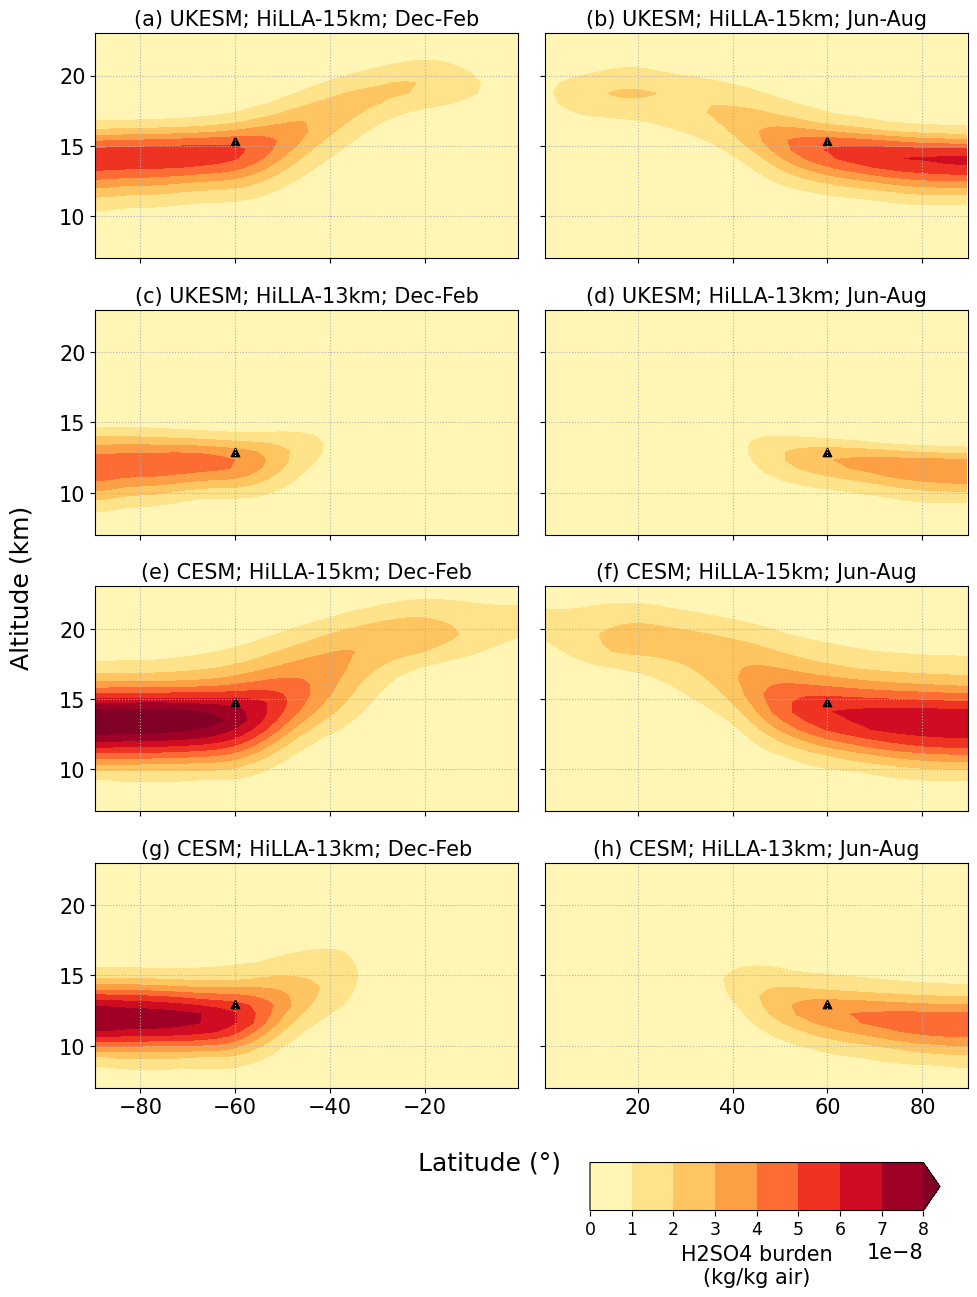

In [41]:
# repeat the plot above, now just summer and winter:

fig, axs = plt.subplots(4, 2, figsize=(10, 12),
                        sharex='col', sharey='all')

heights = [15.36, 12.90, 14.8, 12.95] # NB: CESM values are nominal for now, to fix!
ds_s = [ds_HiLLA_15_UK, ds_HiLLA_13_UK, 
        ds_HiLLA_15_CE, ds_HiLLA_13_CE]

months = [[12, 1, 2], [6, 7, 8]]
xlims = [[-90, 0], [0, 90]]
titles = ['(a) UKESM; HiLLA-15km; Dec-Feb', '(b) UKESM; HiLLA-15km; Jun-Aug',
          '(c) UKESM; HiLLA-13km; Dec-Feb', '(d) UKESM; HiLLA-13km; Jun-Aug',
          '(e) CESM; HiLLA-15km; Dec-Feb', '(f) CESM; HiLLA-15km; Jun-Aug',
          '(g) CESM; HiLLA-13km; Dec-Feb', '(h) CESM; HiLLA-13km; Jun-Aug']

t=0
j=0
for ds in ds_s:
    i=0
    for ms in months:
        
        ax = axs[j, i]
        colorset = 'YlOrRd'
        
        p = ds.where(ds.month.isin(ms), drop=True).mean('month')
        #p = p.where(p.altitude<22000, drop=True)
        p = p.sel(latitude=slice(xlims[i][0], xlims[i][1]))
        if j <2:
            cs=ax.contourf(p.latitude, 0.001*p.altitude,
                           p.h2so4_mmr, cmap=colorset, extend='max',
                           levels = np.arange(0, 9E-8, 1E-8))

        # gnuplot2_r inferno_4, magma_r, YlOrRd
        else:
            cs=ax.contourf(p.latitude, 0.001*p.Z3,
                           p.h2so4_mmr.transpose(), cmap=colorset, extend='max',
                           levels = np.arange(0, 9E-8, 1E-8))
        
        
        ax.grid(ls='dotted')
        #
        ax.set_ylim(7,23)
        
        if i == 0:
            ax.scatter([-60], [heights[j]], marker='^', color='black')
            ax.set_xlim(-89.5, -0.5)
        else:
            ax.scatter([60], [heights[j]], marker='^', color='black')
            ax.set_xlim(0.5, 89.5)
        ax.set_title(titles[t], fontsize='medium')
        i=i+1
        t=t+1
        
    j=j+1
    
fig.supxlabel('Latitude (°)')
fig.supylabel('Altitude (km)')

plt.tight_layout()


cbar_ax1 = fig.add_axes([0.6, -0.02, 0.35, 0.04])
cbar1 = fig.colorbar(cs, cax=cbar_ax1, orientation='horizontal', label='H2SO4 burden\n(kg/kg air)')
cbar1.ax.tick_params(labelsize='small')
plt.savefig('Figures/H2SO4_burden_UKESM_CESM_byseason.jpg', dpi=450, bbox_inches='tight')

plt.show()

## also use the total column burdens to analyse meridional shape of the burdens

In [3]:
load_ds_UK_13 = get_ds('u-dm204dn587', 'loadh2so4', 'AERmon')
load_ds_UK_15 = get_ds('u-dn760', 'loadh2so4', 'AERmon')

S_to_SO4_conv = 96.06/32.065 ## NB i think UKESM is in S units, so converting to SO4 - TO CHECK!!!
SO4_to_S_conv = 32.065/96.06

load_ds_UK_13['loadso4'] = load_ds_UK_13['loadh2so4']*S_to_SO4_conv
load_ds_UK_15['loadso4'] = load_ds_UK_15['loadh2so4']*S_to_SO4_conv

## get UK background 
load_ds_UK_ssp245 = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                                     scenario = 'ssp245', variable='loadso4', 
                                     members=['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2', 'r4i1p1f2', 'r8i1p1f2'], 
                                     table='Emon', grid='gn').sel(time=slice('2035', '2069')).rename({'y':'latitude', 'x':'longitude'}).mean('Ensemble_member')


# load E3SM data:
load_ds_E3_13 = xr.open_dataset(path_archive+'E3SM_data/regridded/burdensSO4/ABURDENSO4.polar.mip.e3sm.01.nc').rename({'lat':'latitude', 'lon':'longitude', 'ABURDENSO4':'loadso4'})
load_ds_E3_15 = xr.open_dataset(path_archive+'E3SM_data/regridded/burdensSO4/ABURDENSO4.polar.mip.e3sm.04.nc').rename({'lat':'latitude', 'lon':'longitude', 'ABURDENSO4':'loadso4'})
load_ds_E3_control = xr.open_dataset(path_archive+'E3SM_data/regridded/burdensSO4/ABURDENSO4.polar.mip.e3sm.control.nc').rename({'lat':'latitude', 'lon':'longitude', 'ABURDENSO4':'loadso4'})
from nc_processing import grid_cell_areas
E3_areas = grid_cell_areas(load_ds_E3_13.longitude, load_ds_E3_13.latitude)

In [4]:

# make E3 into deltas from background:
load_ds_E3_13 = load_ds_E3_13 - load_ds_E3_control
load_ds_E3_15 = load_ds_E3_15 - load_ds_E3_control

In [5]:

load_ds_UK_13 = load_ds_UK_13 - load_ds_UK_ssp245
load_ds_UK_15 = load_ds_UK_15 - load_ds_UK_ssp245

In [6]:
val1 = load_ds_UK_13.isel(time=0).sel(latitude=slice(-40, 40)).mean().loadso4.values.item()
val2 = load_ds_UK_ssp245.sel(time=slice('2035', '2035')).isel(time=0).sel(latitude=slice(-40, 40)).mean().loadso4.values.item()

#val1 = load_ds_UK_13.isel(time=0).mean().loadso4.values.item()
#val2 = load_ds_UK_ssp245.sel(time=slice('2035', '2035')).isel(time=0).mean().loadso4.values.item()

S_to_SO4_conv = 96.06/32.065 

val2/(val1*S_to_SO4_conv)

9.944500512557067

In [7]:


# group by year
load_ds_UK_13 = load_ds_UK_13.sel(time=slice('2050', '2069')).groupby('time.month').mean(dim='time').load()
load_ds_UK_15 = load_ds_UK_15.sel(time=slice('2050', '2069')).groupby('time.month').mean(dim='time').load()



load_ds_E3_13 = load_ds_E3_13.sel(time=slice('2050', '2069')).groupby('time.month').mean(dim='time').load()
load_ds_E3_15 = load_ds_E3_15.sel(time=slice('2050', '2069')).groupby('time.month').mean(dim='time').load()


#load_ds_UK_ssp245 = load_ds_UK_ssp245.sel(time=slice('2050', '2069')).groupby('time.month').mean(dim='time')

# get grid cell areas:
areacella = xr.open_dataset('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/fx/areacella/gn/latest/areacella_fx_UKESM1-0-LL_piControl_r1i1p1f2_gn.nc')
areacella = areacella.rename({'lat':'latitude', 'lon':'longitude'})

# make into total load rather than per m2
load_ds_UK_13['loadso4_kg'] = load_ds_UK_13['loadso4']*areacella['areacella']
load_ds_UK_15['loadso4_kg'] = load_ds_UK_15['loadso4']*areacella['areacella']

load_ds_E3_13['loadso4_kg'] = load_ds_E3_13['loadso4']*E3_areas
load_ds_E3_15['loadso4_kg'] = load_ds_E3_15['loadso4']*E3_areas

In [8]:
summer_load_UK_13 = load_ds_UK_13.where(load_ds_UK_13.month.isin([6, 7, 8]), drop=True).mean('month')
winter_load_UK_13 = load_ds_UK_13.where(load_ds_UK_13.month.isin([1, 2, 12]), drop=True).mean('month')

summer_load_UK_15 = load_ds_UK_15.where(load_ds_UK_15.month.isin([6, 7, 8]), drop=True).mean('month')
winter_load_UK_15 = load_ds_UK_15.where(load_ds_UK_15.month.isin([1, 2, 12]), drop=True).mean('month')

summer_load_E3_13 = load_ds_E3_13.where(load_ds_E3_13.month.isin([6, 7, 8]), drop=True).mean('month')
winter_load_E3_13 = load_ds_E3_13.where(load_ds_E3_13.month.isin([1, 2, 12]), drop=True).mean('month')

summer_load_E3_15 = load_ds_E3_15.where(load_ds_E3_15.month.isin([6, 7, 8]), drop=True).mean('month')
winter_load_E3_15 = load_ds_E3_15.where(load_ds_E3_15.month.isin([1, 2, 12]), drop=True).mean('month')



In [9]:
### also plot some maps: 

import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

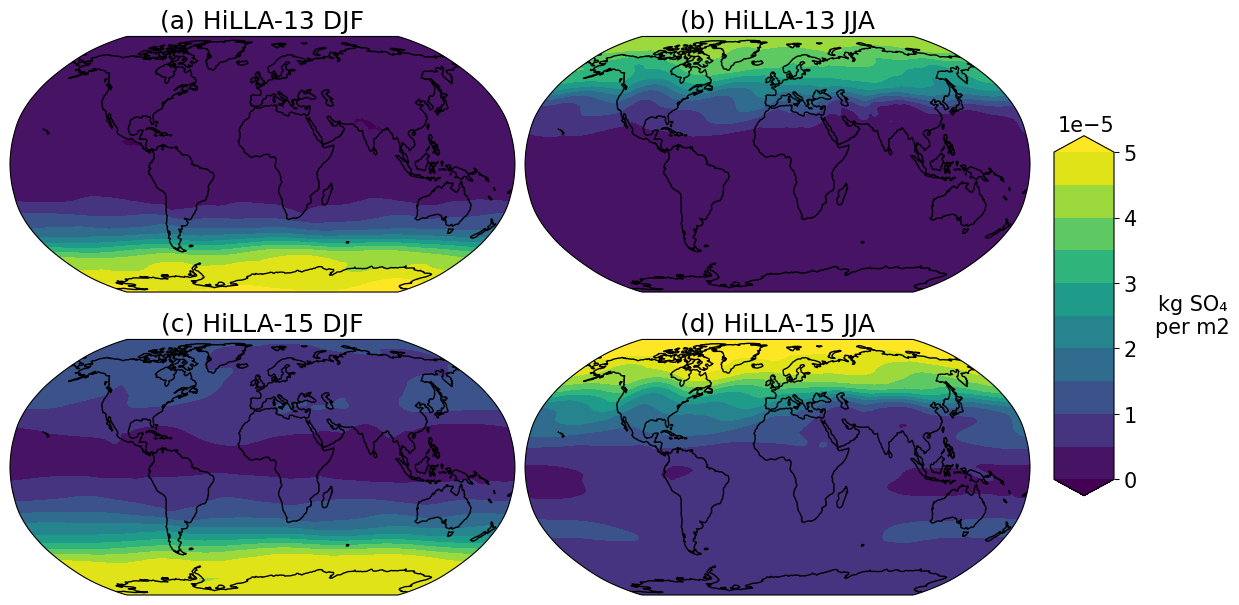

In [10]:
## UKESM

cols = 'viridis'
clevs=np.arange(0,5.5E-5,0.5E-5) 

fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(12,6))

titles = ['(a) HiLLA-13 DJF', '(b) HiLLA-13 JJA', '(c) HiLLA-15 DJF', '(d) HiLLA-15 JJA']

var = 'loadso4'

to_plot = [winter_load_UK_13, summer_load_UK_13,
           winter_load_UK_15, summer_load_UK_15]

i=0
for ax in axs.flatten():
    ax.set_title(titles[i])
    d = to_plot[i]
    d = d[var]
    data,lons=add_cyclic_point(d,coord=d['longitude'])
    cs=ax.contourf(lons,d['latitude'],data,clevs,
                   transform = ccrs.PlateCarree(),
                   cmap=cols,
                   extend='both')
    ax.coastlines()
    i=i+1

plt.tight_layout()
# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0, top=1, left=0, right=0.85,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.87, 0.2, 0.05, 0.6])

# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='vertical')
cbar.set_label('kg SO₄\nper m2', rotation=0, labelpad=40)
cbar.ax.yaxis.label.set_va('center')
#
plt.savefig('Figures/spatial_{}_UKESM.jpg'.format(var), dpi=300, bbox_inches='tight')

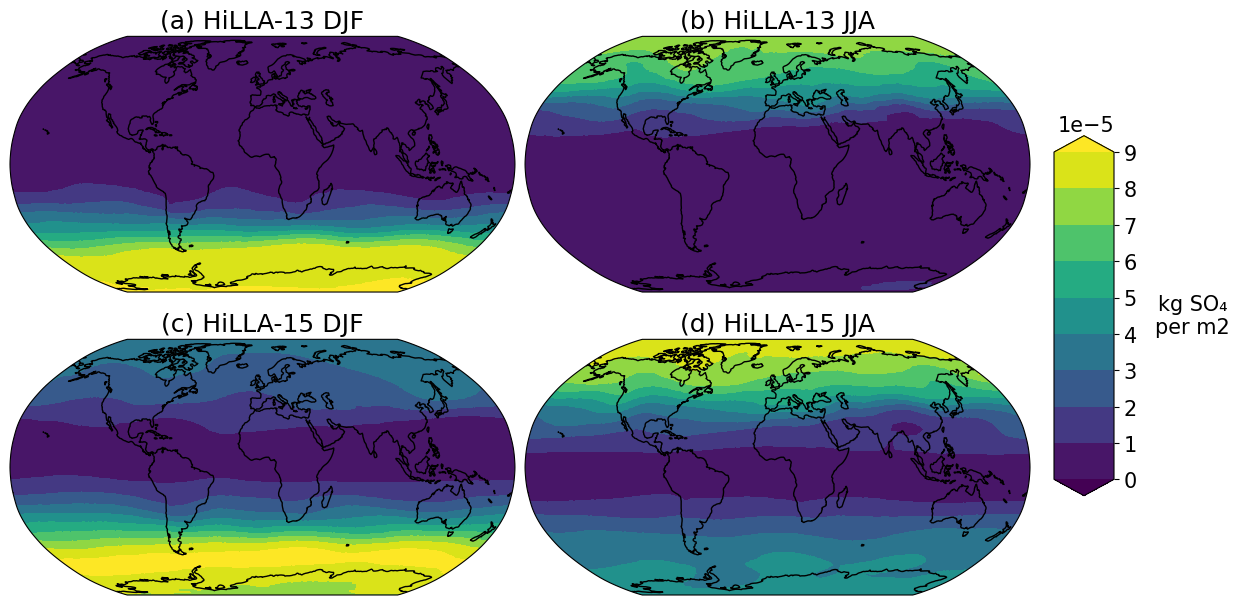

In [11]:
## E3SM

## UKESM

cols = 'viridis'
clevs=np.arange(0,10E-5,1E-5) 

fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(12,6))

titles = ['(a) HiLLA-13 DJF', '(b) HiLLA-13 JJA', '(c) HiLLA-15 DJF', '(d) HiLLA-15 JJA']

var = 'loadso4'

to_plot = [winter_load_E3_13, summer_load_E3_13,
           winter_load_E3_15, summer_load_E3_15]

i=0
for ax in axs.flatten():
    ax.set_title(titles[i])
    d = to_plot[i]
    d = d[var]
    data,lons=add_cyclic_point(d,coord=d['longitude'])
    cs=ax.contourf(lons,d['latitude'],data,clevs,
                   transform = ccrs.PlateCarree(),
                   cmap=cols,
                   extend='both')
    ax.coastlines()
    i=i+1

#plt.tight_layout()
# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0, top=1, left=0, right=0.85,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.87, 0.2, 0.05, 0.6])

# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='vertical')
cbar.set_label('kg SO₄\nper m2', rotation=0, labelpad=40)
cbar.ax.yaxis.label.set_va('center')

#
plt.savefig('Figures/spatial_{}_E3SM.jpg'.format(var), dpi=300, bbox_inches='tight')

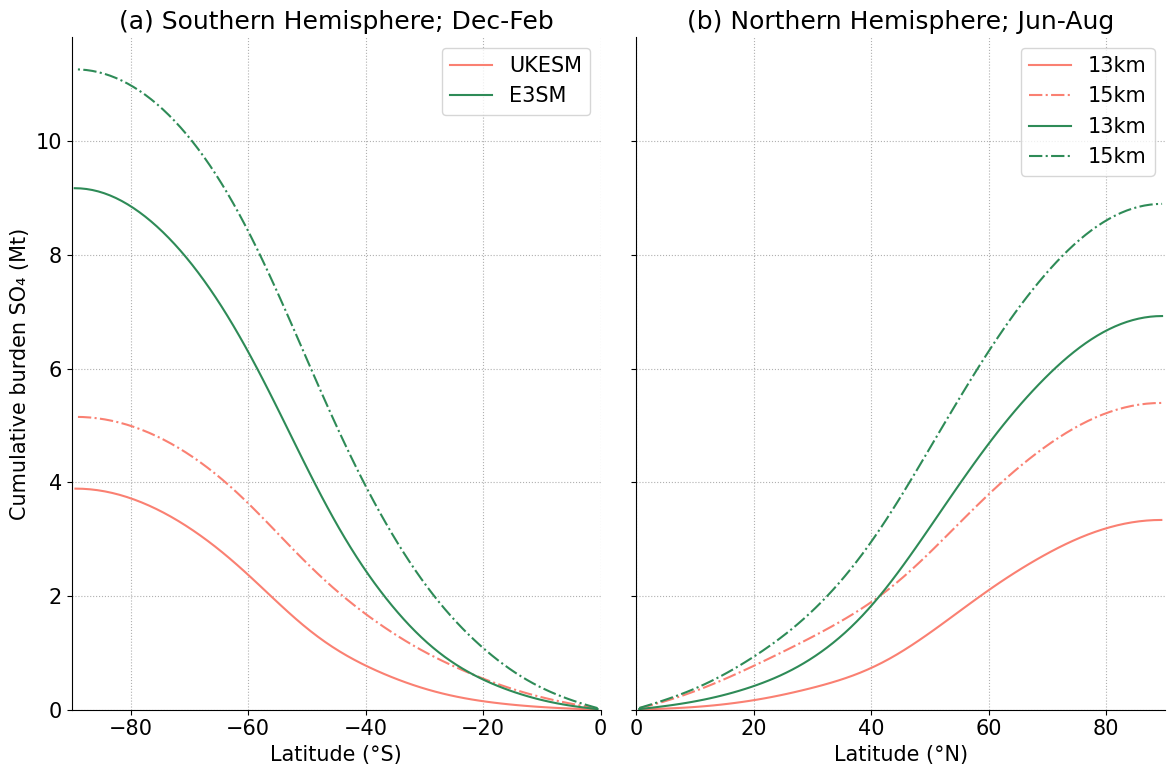

In [12]:
alt_linestyles = {'13km':'solid', '15km':'-.'}

ds_north_15_UK = summer_load_UK_15.sum('longitude').sel(latitude=slice(0, 90)).sortby('latitude')
ds_south_15_UK = winter_load_UK_15.sum('longitude').sel(latitude=slice(-90, 0)).sortby('latitude', ascending=False)
ds_north_13_UK = summer_load_UK_13.sum('longitude').sel(latitude=slice(0, 90)).sortby('latitude')
ds_south_13_UK = winter_load_UK_13.sum('longitude').sel(latitude=slice(-90, 0)).sortby('latitude', ascending=False)

ds_north_15_E3 = summer_load_E3_15.sum('longitude').sel(latitude=slice(0, 90)).sortby('latitude')
ds_south_15_E3 = winter_load_E3_15.sum('longitude').sel(latitude=slice(-90, 0)).sortby('latitude', ascending=False)
ds_north_13_E3 = summer_load_E3_13.sum('longitude').sel(latitude=slice(0, 90)).sortby('latitude')
ds_south_13_E3 = winter_load_E3_13.sum('longitude').sel(latitude=slice(-90, 0)).sortby('latitude', ascending=False)

cumulative_load_north_13_UK = ds_north_13_UK['loadso4_kg'].cumsum(dim='latitude')
cumulative_load_north_15_UK = ds_north_15_UK['loadso4_kg'].cumsum(dim='latitude')
cumulative_load_south_13_UK = ds_south_13_UK['loadso4_kg'].cumsum(dim='latitude')
cumulative_load_south_15_UK = ds_south_15_UK['loadso4_kg'].cumsum(dim='latitude')

cumulative_load_north_13_E3 = ds_north_13_E3['loadso4_kg'].cumsum(dim='latitude')
cumulative_load_north_15_E3 = ds_north_15_E3['loadso4_kg'].cumsum(dim='latitude')
cumulative_load_south_13_E3 = ds_south_13_E3['loadso4_kg'].cumsum(dim='latitude')
cumulative_load_south_15_E3 = ds_south_15_E3['loadso4_kg'].cumsum(dim='latitude')

fig, axs = plt.subplots(1, 2, figsize=(12, 8), sharex=False, sharey=True)

ax=axs[1]

# UK
ax.plot(cumulative_load_north_13_UK['latitude'], 1E-9*cumulative_load_north_13_UK, linestyle=alt_linestyles['13km'], color=model_colors['UKESM'], label='13km')
ax.plot(cumulative_load_north_15_UK['latitude'], 1E-9*cumulative_load_north_15_UK, linestyle=alt_linestyles['15km'], color=model_colors['UKESM'], label='15km')
# E3
ax.plot(cumulative_load_north_13_E3['latitude'], 1E-9*cumulative_load_north_13_E3, linestyle=alt_linestyles['13km'], color=model_colors['E3SM'], label='13km')
ax.plot(cumulative_load_north_15_E3['latitude'], 1E-9*cumulative_load_north_15_E3, linestyle=alt_linestyles['15km'], color=model_colors['E3SM'], label='15km')

ax.legend()
ax.set_title('(b) Northern Hemisphere; Jun-Aug')
ax.set_xlabel('Latitude (°N)')
#ax.set_ylabel('Cumulative burden H2SO4 (Mt)', fontsize=12)
ax.set_xlim(0, 90) 

ax = axs[0]
ax.plot(cumulative_load_south_13_UK['latitude'], 1E-9*cumulative_load_south_13_UK, linestyle=alt_linestyles['13km'], color=model_colors['UKESM'], label='UKESM')
ax.plot(cumulative_load_south_15_UK['latitude'], 1E-9*cumulative_load_south_15_UK, linestyle=alt_linestyles['15km'], color=model_colors['UKESM'])
ax.plot(cumulative_load_south_13_E3['latitude'], 1E-9*cumulative_load_south_13_E3, linestyle=alt_linestyles['13km'], color=model_colors['E3SM'], label='E3SM')
ax.plot(cumulative_load_south_15_E3['latitude'], 1E-9*cumulative_load_south_15_E3, linestyle=alt_linestyles['15km'], color=model_colors['E3SM'])
ax.legend()
ax.set_title('(a) Southern Hemisphere; Dec-Feb')
ax.set_xlabel('Latitude (°S)')
ax.set_ylabel('Cumulative burden SO₄ (Mt)')
ax.set_xlim(-90, 0)


for ax in axs:
    ax.set_ylim(0, None)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')


plt.tight_layout() 

plt.savefig('Figures/cumulative_zonal_so4_burdens.jpg'.format(var), dpi=300)
plt.show()

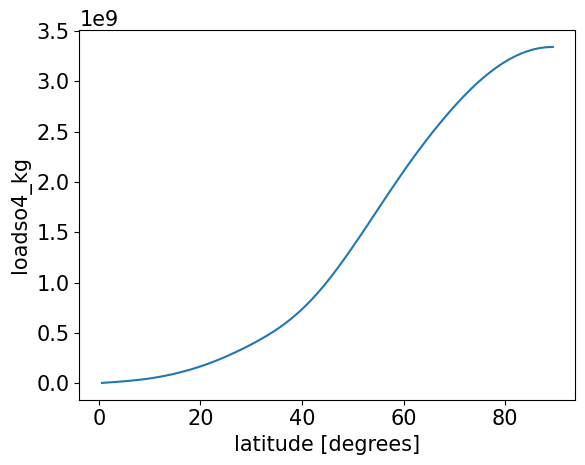

In [13]:
cumulative_load_north_13_UK.plot()

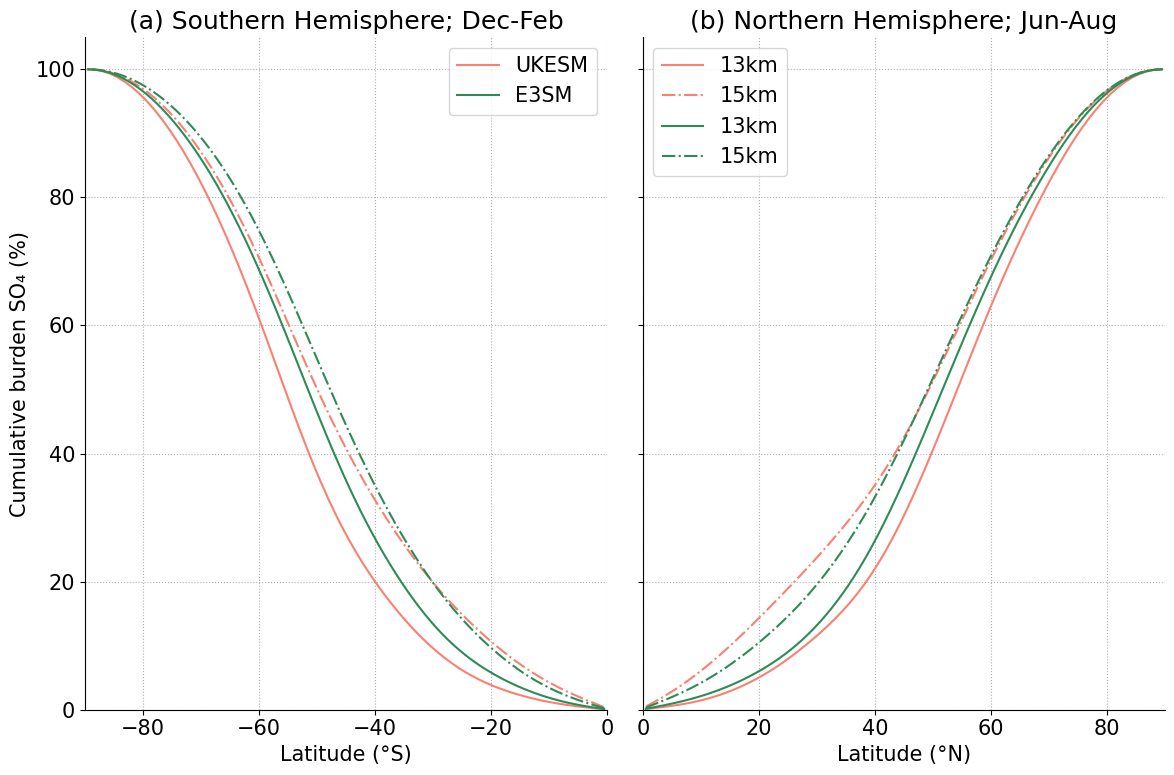

In [14]:
### repeat the above plot, as fraction of total for each run: 

fig, axs = plt.subplots(1, 2, figsize=(12, 8), sharex=False, sharey=True)

ax=axs[1]

# UK
ax.plot(cumulative_load_north_13_UK['latitude'], 100*cumulative_load_north_13_UK/cumulative_load_north_13_UK.max(), linestyle=alt_linestyles['13km'], color=model_colors['UKESM'], label='13km')
ax.plot(cumulative_load_north_15_UK['latitude'], 100*cumulative_load_north_15_UK/cumulative_load_north_15_UK.max(), linestyle=alt_linestyles['15km'], color=model_colors['UKESM'], label='15km')
# E3
ax.plot(cumulative_load_north_13_E3['latitude'], 100*cumulative_load_north_13_E3/cumulative_load_north_13_E3.max(), linestyle=alt_linestyles['13km'], color=model_colors['E3SM'], label='13km')
ax.plot(cumulative_load_north_15_E3['latitude'], 100*cumulative_load_north_15_E3/cumulative_load_north_15_E3.max(), linestyle=alt_linestyles['15km'], color=model_colors['E3SM'], label='15km')

ax.legend()
ax.set_title('(b) Northern Hemisphere; Jun-Aug')
ax.set_xlabel('Latitude (°N)')
#ax.set_ylabel('Cumulative burden H2SO4 (Mt)', fontsize=12)
ax.set_xlim(0, 90) 

ax = axs[0]
ax.plot(cumulative_load_south_13_UK['latitude'], 100*cumulative_load_south_13_UK/cumulative_load_south_13_UK.max(), linestyle=alt_linestyles['13km'], color=model_colors['UKESM'], label='UKESM')
ax.plot(cumulative_load_south_15_UK['latitude'], 100*cumulative_load_south_15_UK/cumulative_load_south_15_UK.max(), linestyle=alt_linestyles['15km'], color=model_colors['UKESM'])
ax.plot(cumulative_load_south_13_E3['latitude'], 100*cumulative_load_south_13_E3/cumulative_load_south_13_E3.max(), linestyle=alt_linestyles['13km'], color=model_colors['E3SM'], label='E3SM')
ax.plot(cumulative_load_south_15_E3['latitude'], 100*cumulative_load_south_15_E3/cumulative_load_south_15_E3.max(), linestyle=alt_linestyles['15km'], color=model_colors['E3SM'])
ax.legend()
ax.set_title('(a) Southern Hemisphere; Dec-Feb')
ax.set_xlabel('Latitude (°S)')
ax.set_ylabel('Cumulative burden SO₄ (%)')
ax.set_xlim(-90, 0)


for ax in axs:
    ax.set_ylim(0, None)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')


plt.tight_layout() 

plt.savefig('Figures/cumulative_zonal_so4_burdens_frac.jpg'.format(var), dpi=300)
plt.show()

In [15]:
### print ratios of total NH burden:
print(cumulative_load_north_15_UK.max().item()/cumulative_load_north_13_UK.max().item())
print(cumulative_load_north_15_E3.max().item()/cumulative_load_north_13_E3.max().item())


1.6165791805033858
1.2848884175468225


In [16]:
### print the latitude of 50th percentile of cumulative burden: 
for load in [cumulative_load_north_13_UK, cumulative_load_north_15_UK,
             cumulative_load_south_13_UK, cumulative_load_south_15_UK]:
    maxval = np.max(load.values)
    halfval = maxval/2

    nearest_index = np.abs(load.values - halfval).argmin()
    nearest_coord = load.coords[load.dims[0]].values[nearest_index] # Get the coordinate value

    print('UKESM', maxval, halfval, nearest_index, nearest_coord)

   
for load in [cumulative_load_north_13_E3, cumulative_load_north_15_E3,
             cumulative_load_south_13_E3, cumulative_load_south_15_E3]:
    maxval = np.max(load.values)
    halfval = maxval/2

    nearest_index = np.abs(load.values - halfval).argmin()
    nearest_coord = load.coords[load.dims[0]].values[nearest_index] # Get the coordinate value

    print('E3SM', maxval, halfval, nearest_index, nearest_coord)

UKESM 3339597000.0 1669798528.0 43 54.375
UKESM 5398723000.0 2699361536.0 39 49.375
UKESM 3891069000.0 1945534464.0 44 -55.625
UKESM 5153689000.0 2576844544.0 39 -49.375
E3SM 6928109229.136878 3464054614.568439 51 51.5
E3SM 8901847304.01722 4450923652.00861 49 49.5
E3SM 9177917098.861355 4588958549.430677 51 -51.5
E3SM 11269722252.97392 5634861126.48696 47 -47.5


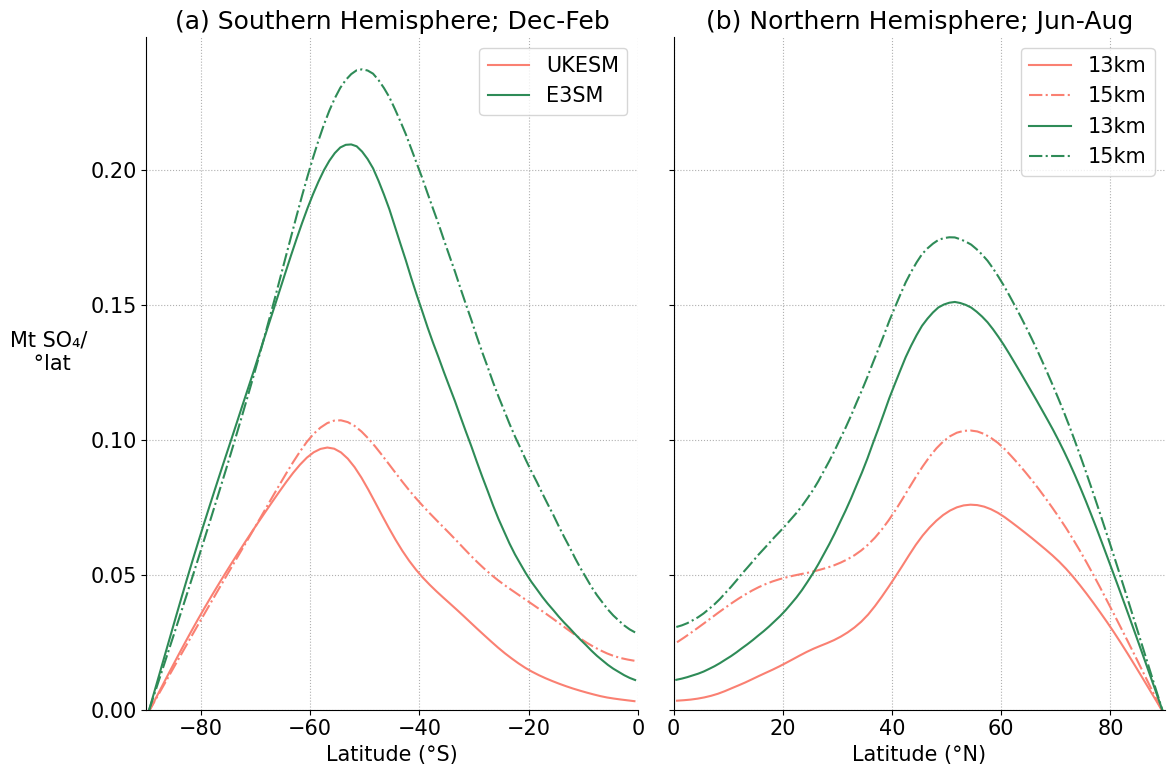

In [17]:
## repeat, now with the derivate to show the total burden per degree latitude

alt_linestyles = {'13km':'solid', '15km':'-.'}

ds_north_15_UK = summer_load_UK_15.sum('longitude').sel(latitude=slice(0, 90)).sortby('latitude')
ds_south_15_UK = winter_load_UK_15.sum('longitude').sel(latitude=slice(-90, 0)).sortby('latitude', ascending=False)
ds_north_13_UK = summer_load_UK_13.sum('longitude').sel(latitude=slice(0, 90)).sortby('latitude')
ds_south_13_UK = winter_load_UK_13.sum('longitude').sel(latitude=slice(-90, 0)).sortby('latitude', ascending=False)


perdeg_load_north_13_UK = ds_north_13_UK['loadso4_kg'].cumsum(dim='latitude').differentiate(coord='latitude', edge_order=2)
perdeg_load_north_15_UK = ds_north_15_UK['loadso4_kg'].cumsum(dim='latitude').differentiate(coord='latitude', edge_order=2)
perdeg_load_south_13_UK = -ds_south_13_UK['loadso4_kg'].cumsum(dim='latitude').differentiate(coord='latitude', edge_order=2)
perdeg_load_south_15_UK = -ds_south_15_UK['loadso4_kg'].cumsum(dim='latitude').differentiate(coord='latitude', edge_order=2)


ds_north_15_E3 = summer_load_E3_15.sum('longitude').sel(latitude=slice(0, 90)).sortby('latitude')
ds_south_15_E3 = winter_load_E3_15.sum('longitude').sel(latitude=slice(-90, 0)).sortby('latitude', ascending=False)
ds_north_13_E3 = summer_load_E3_13.sum('longitude').sel(latitude=slice(0, 90)).sortby('latitude')
ds_south_13_E3 = winter_load_E3_13.sum('longitude').sel(latitude=slice(-90, 0)).sortby('latitude', ascending=False)

perdeg_load_north_13_E3 = ds_north_13_E3['loadso4_kg'].cumsum(dim='latitude').differentiate(coord='latitude', edge_order=2)
perdeg_load_north_15_E3 = ds_north_15_E3['loadso4_kg'].cumsum(dim='latitude').differentiate(coord='latitude', edge_order=2)
perdeg_load_south_13_E3 = -ds_south_13_E3['loadso4_kg'].cumsum(dim='latitude').differentiate(coord='latitude', edge_order=2)
perdeg_load_south_15_E3 = -ds_south_15_E3['loadso4_kg'].cumsum(dim='latitude').differentiate(coord='latitude', edge_order=2)


fig, axs = plt.subplots(1, 2, figsize=(12, 8), sharex=False, sharey=True)

ax=axs[1]

ax.plot(perdeg_load_north_13_UK['latitude'], 1E-9*perdeg_load_north_13_UK, linestyle=alt_linestyles['13km'], color=model_colors['UKESM'], label='13km')
ax.plot(perdeg_load_north_15_UK['latitude'], 1E-9*perdeg_load_north_15_UK, linestyle=alt_linestyles['15km'], color=model_colors['UKESM'], label='15km')
# E3
ax.plot(perdeg_load_north_13_E3['latitude'], 1E-9*perdeg_load_north_13_E3, linestyle=alt_linestyles['13km'], color=model_colors['E3SM'], label='13km')
ax.plot(perdeg_load_north_15_E3['latitude'], 1E-9*perdeg_load_north_15_E3, linestyle=alt_linestyles['15km'], color=model_colors['E3SM'], label='15km')

ax.legend()
ax.set_title('(b) Northern Hemisphere; Jun-Aug')
ax.set_xlabel('Latitude (°N)')
#ax.set_ylabel('Cumulative burden H2SO4 (Mt)', fontsize=12)
ax.set_xlim(0, 90) 

ax = axs[0]
ax.plot(perdeg_load_south_13_UK['latitude'], 1E-9*perdeg_load_south_13_UK, linestyle=alt_linestyles['13km'], color=model_colors['UKESM'], label='UKESM')
ax.plot(perdeg_load_south_15_UK['latitude'], 1E-9*perdeg_load_south_15_UK, linestyle=alt_linestyles['15km'], color=model_colors['UKESM'])
ax.plot(perdeg_load_south_13_E3['latitude'], 1E-9*perdeg_load_south_13_E3, linestyle=alt_linestyles['13km'], color=model_colors['E3SM'], label='E3SM')
ax.plot(perdeg_load_south_15_E3['latitude'], 1E-9*perdeg_load_south_15_E3, linestyle=alt_linestyles['15km'], color=model_colors['E3SM'])
ax.legend()
ax.set_title('(a) Southern Hemisphere; Dec-Feb')
ax.set_xlabel('Latitude (°S)')
ax.set_ylabel('Mt SO₄/\n °lat', rotation=0, labelpad=30)
ax.set_xlim(-90, 0)


for ax in axs:
    ax.set_ylim(0, None)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')


plt.tight_layout()


plt.savefig('Figures/zonaltotal_so4_burdens.jpg'.format(var), dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# fraction of total burden equatorward of injection:
ds_north_13_UK['loadso4_kg']

<xarray.DataArray 'loadso4_kg' (latitude: 72)> Size: 288B
array([ 4169067.8,  4298450.5,  4516130.5,  4868506. ,  5375046. ,
        6034789. ,  6879357.5,  7936268. ,  9254774. , 10633634. ,
       11890201. , 13368557. , 14887268. , 16388927. , 17815452. ,
       19279364. , 20912812. , 22573894. , 24296940. , 26005078. ,
       27578968. , 28968032. , 30228388. , 31515958. , 32999392. ,
       34789536. , 36866420. , 39350352. , 42283240. , 45916520. ,
       50115316. , 54604076. , 59290448. , 64107088. , 69124464. ,
       74146568. , 78790536. , 82737656. , 86147840. , 89064296. ,
       91426848. , 93180520. , 94421728. , 94974600. , 95087736. ,
       94583440. , 93679968. , 92165488. , 90412640. , 88103448. ,
       85728032. , 83296096. , 80813856. , 78243568. , 75594632. ,
       72975056. , 70126912. , 67067304. , 63597864. , 59878224. ,
       55877680. , 51725768. , 47385468. , 42927284. , 38364952. ,
       33583144. , 28647096. , 23582572. , 18402852. , 13170389. ,
        7920620. ,  2641780. ], dtype=float32)
Coordinates:
  * latitude  (latitude) float64 576B 0.625 1.875 3.125 ... 86.88 88.12 89.38

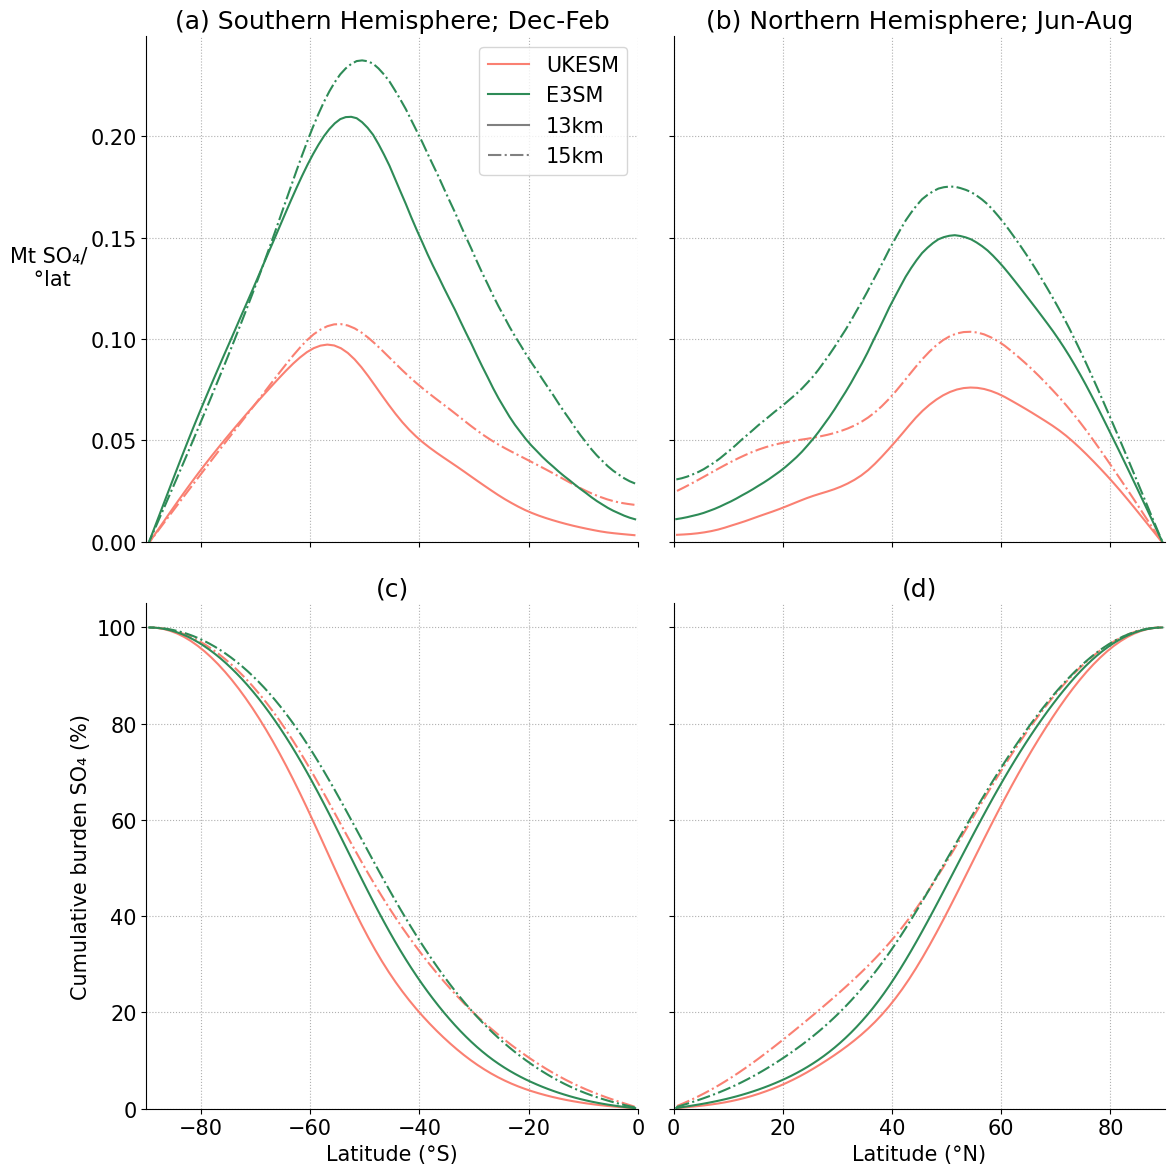

In [29]:
### plot both in one:



fig, axs = plt.subplots(2, 2, figsize=(12, 12), sharex='col', sharey='row')

ax=axs.flatten()[3]

# UK
ax.plot(cumulative_load_north_13_UK['latitude'], 100*cumulative_load_north_13_UK/cumulative_load_north_13_UK.max(), linestyle=alt_linestyles['13km'], color=model_colors['UKESM'], label='13km')
ax.plot(cumulative_load_north_15_UK['latitude'], 100*cumulative_load_north_15_UK/cumulative_load_north_15_UK.max(), linestyle=alt_linestyles['15km'], color=model_colors['UKESM'], label='15km')
# E3
ax.plot(cumulative_load_north_13_E3['latitude'], 100*cumulative_load_north_13_E3/cumulative_load_north_13_E3.max(), linestyle=alt_linestyles['13km'], color=model_colors['E3SM'], label='13km')
ax.plot(cumulative_load_north_15_E3['latitude'], 100*cumulative_load_north_15_E3/cumulative_load_north_15_E3.max(), linestyle=alt_linestyles['15km'], color=model_colors['E3SM'], label='15km')

#ax.legend()
ax.set_title('(d)')
ax.set_xlabel('Latitude (°N)')
#ax.set_ylabel('Cumulative burden H2SO4 (Mt)', fontsize=12)
ax.set_xlim(0, 90) 

ax = axs.flatten()[2]
ax.plot(cumulative_load_south_13_UK['latitude'], 100*cumulative_load_south_13_UK/cumulative_load_south_13_UK.max(), linestyle=alt_linestyles['13km'], color=model_colors['UKESM'], label='UKESM')
ax.plot(cumulative_load_south_15_UK['latitude'], 100*cumulative_load_south_15_UK/cumulative_load_south_15_UK.max(), linestyle=alt_linestyles['15km'], color=model_colors['UKESM'])
ax.plot(cumulative_load_south_13_E3['latitude'], 100*cumulative_load_south_13_E3/cumulative_load_south_13_E3.max(), linestyle=alt_linestyles['13km'], color=model_colors['E3SM'], label='E3SM')
ax.plot(cumulative_load_south_15_E3['latitude'], 100*cumulative_load_south_15_E3/cumulative_load_south_15_E3.max(), linestyle=alt_linestyles['15km'], color=model_colors['E3SM'])
#ax.legend()
ax.set_title('(c)')
ax.set_ylabel('Cumulative burden SO₄ (%)')
ax.set_xlabel('Latitude (°S)')
ax.set_xlim(-90, 0)


ax=axs.flatten()[1]

ax.plot(perdeg_load_north_13_UK['latitude'], 1E-9*perdeg_load_north_13_UK, linestyle=alt_linestyles['13km'], color=model_colors['UKESM'], label='13km')
ax.plot(perdeg_load_north_15_UK['latitude'], 1E-9*perdeg_load_north_15_UK, linestyle=alt_linestyles['15km'], color=model_colors['UKESM'], label='15km')
# E3
ax.plot(perdeg_load_north_13_E3['latitude'], 1E-9*perdeg_load_north_13_E3, linestyle=alt_linestyles['13km'], color=model_colors['E3SM'], label='13km')
ax.plot(perdeg_load_north_15_E3['latitude'], 1E-9*perdeg_load_north_15_E3, linestyle=alt_linestyles['15km'], color=model_colors['E3SM'], label='15km')

#ax.legend()
ax.set_title('(b) Northern Hemisphere; Jun-Aug')

#ax.set_ylabel('Cumulative burden H2SO4 (Mt)', fontsize=12)
ax.set_xlim(0, 90) 

ax = axs.flatten()[0]
ax.plot(perdeg_load_south_13_UK['latitude'], 1E-9*perdeg_load_south_13_UK, linestyle=alt_linestyles['13km'], color=model_colors['UKESM'], label='UKESM')
ax.plot(perdeg_load_south_15_UK['latitude'], 1E-9*perdeg_load_south_15_UK, linestyle=alt_linestyles['15km'], color=model_colors['UKESM'])
ax.plot(perdeg_load_south_13_E3['latitude'], 1E-9*perdeg_load_south_13_E3, linestyle=alt_linestyles['13km'], color=model_colors['E3SM'], label='E3SM')
ax.plot(perdeg_load_south_15_E3['latitude'], 1E-9*perdeg_load_south_15_E3, linestyle=alt_linestyles['15km'], color=model_colors['E3SM'])
for alt in ['13km', '15km']:
    ax.plot([], [], linestyle=alt_linestyles[alt], c='gray', label=alt)
ax.legend()
ax.set_title('(a) Southern Hemisphere; Dec-Feb')

ax.set_ylabel('Mt SO₄/\n °lat', rotation=0, labelpad=30)
ax.set_xlim(-90, 0)


for ax in axs.flatten():
    ax.set_ylim(0, None)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')


plt.tight_layout()


plt.savefig('Figures/zonaltotal_so4_burdens_all.jpg'.format(var), dpi=300, bbox_inches='tight')
plt.show()